In [ ]:
# Population vs Sample
# Sample
# h_bar = mean of h_i for i in range(n)


In [ ]:
# Gausian distribution 
# is a bell-shaped curve that describes how data points are distributed around the mean.

# pdf distribution of gaussian distribution
# x: continuous variable

# mean and variance can tell a lot about the shape of the distribution, but they don't capture everything.

# p(X=x) = p(x) = (1 / (sigma * sqrt(2 * pi))) * exp(-0.5 * ((x - mu) / sigma) ** 2)

# for mu = 0 and sigma-1
# p(x) = (1 / sqrt(2 * pi)) * exp(-0.5 * x^2)
# form of graph: y = exp(-x**2) => bell-shaped curve centered at 0

# properties
# 1. as x moves away from mu, y decreases exponentially
# 2. symmetric around the mean

In [2]:
# in normal distribution, 
# between first neg variance and first positive variance, we have about 68.2% of the data
# between second neg variance and second positive variance, we have about 95.4% of the data
# between third neg variance and third positive variance, we have about 99.7% of the data
# 68-95-99.7 rule (empirical rule) -> helps us understand how data is distributed in a normal distribution.

In [3]:
# Symmetric distribution
# Assymmetric distribution
# kurtosis: how heavy are the tails of the distribution? <- peakness of the distribution

In [4]:
# Standardization (Z-score normalization)
# z = (x - mu) / sigma
# This transformation centers the data around 0 and scales it to have a standard deviation of 1.

In [5]:
# Kernel density estimation (KDE)
# is a non-parametric way to estimate the probability density function of a random variable.
# histograms -> pdf
# variance in every kernel is determined by the bandwidth parameter, which controls the smoothness of the resulting density curve.

In [ ]:
# Sampling distribution and Central Limit Theorem (CLT)
# Sampling distribution: the probability distribution of a statistic (like the mean) calculated from a sample 

# Central Limit theorem
# states that the sampling distribution of the sample mean will approach a normal distribution as the sample size increases, regardless of the original distribution of the data.
# mean = mean of the population
# variance = variance of the population / n (sample size)
# population distribution (could be any distribution)  -> sample distribution -> sampling distribution of the sample mean -> normal distribution (as n increases)
# usually n >= 30 is considered sufficient for the CLT to hold, but it can depend on the shape of the original distribution.

In [ ]:
# Quantile Quantile plot (QQ plot)
# is a graphical tool to assess if a dataset follows a particular distribution, often the normal distribution
# plots the quantiles of the data against the quantiles of the theoretical distribution
## How to
## 1. Sort the data in ascending order
## 2. Calculate the quantiles of the data
## 3. Calculate the quantiles of the theoretical distribution
## 4. Plot the quantiles against each other
## 5. If the points approximately lie on a straight line, the data is likely to follow the theoretical distribution.

# if number of data points are small, qq plot may not be very informative
# Others are KS, AD testing, etc.

In [10]:
import numpy as np
import pylab
import scipy.stats as stats

# N(0, 1)
std_normal = np.random.normal(loc=0, scale=1, size=1000)

# get percentiles of the data
# for i in range(0, 101):
#     print(i, np.percentile(std_normal, i))

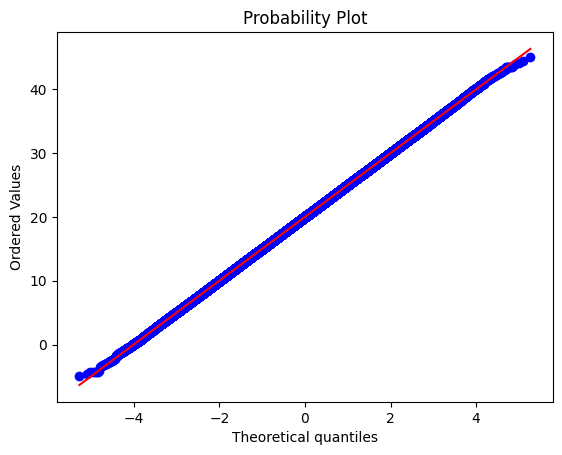

In [16]:
measurements = np.random.normal(loc=20, scale=5, size=10000000)

stats.probplot(measurements, dist="norm", plot=pylab)
pylab.show()

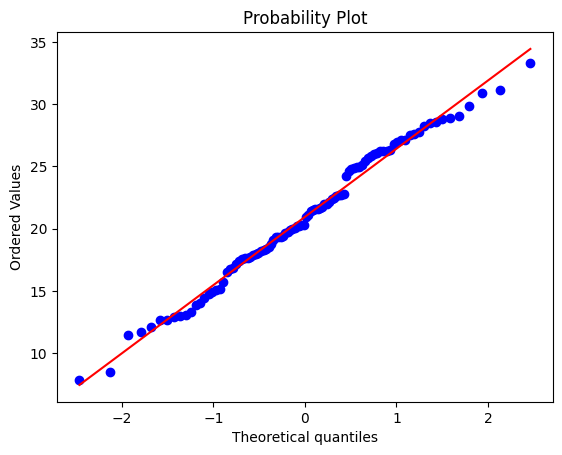

In [17]:
measurements = np.random.normal(loc=20, scale=5, size=100)

stats.probplot(measurements, dist="norm", plot=pylab)
pylab.show()

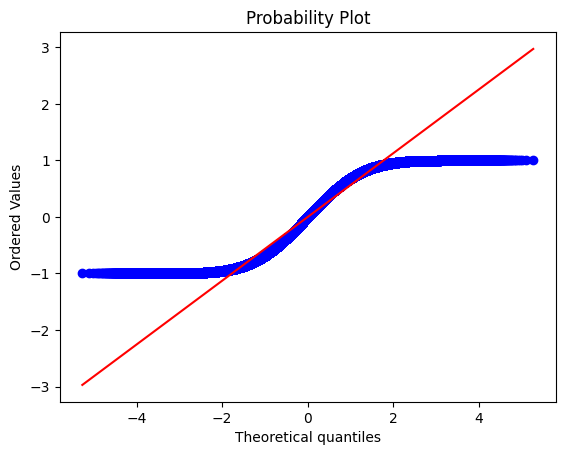

In [18]:
measurements = np.random.uniform(low=-1, high=1, size=10000000)

stats.probplot(measurements, dist="norm", plot=pylab)
pylab.show()

# Chebyshev's Inequality

In [19]:
# X ~ N(meu, sigma)
# p(meu - 2 * sigma <= X <= meu + 2 * sigma) = 0.954
# Same 68-95-99.7 rule

In [ ]:
# What is We don't know the distribution but only meu and sigma?
# p(|x - meu| >= k * sigma) <= 1 / k^2 (Chebyshev's inequality)
# or p(|x - meu| < k * sigma) >= 1 - (1 / k^2)

# Uniform Distribution

In [ ]:
# Discrete, Continuous 
# continuous -> pdf (prob distribution function), cdf
# discrete -> pmf (prob mass function), cdf

# Random number generator (uniform distribution)

In [24]:
from sklearn import datasets
iris = datasets.load_iris()
print(iris.data[1:3])

[[4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]


In [47]:
# sample 30 points randomly from the 150 point dataset 

n = 150
m = 30 
p = m / n

sampled_data = []
for i in range(n):
    if np.random.rand() < p:
        sampled_data.append(iris.data[i])
print(len(sampled_data))

36


# Bernoulli and Binomial Distribution (Discrete Distributions)

In [ ]:
# Bernoulli distribution
# is a discrete probability distribution that models a random experiment with exactly two possible outcomes: success (usually denoted as 1) and failure (usually denoted as 0).

# Binomial distribution
# Y ~ Bin(n, p) where n is the number of trials and p is the probability of success on an individual trial.

# pmf = (n choose k) * p^k * (1-p)^(n-k) where k is the number of successes in n trials

# Log-Normal, Pareto Distribution

In [50]:
# Log-Normal distribution
# a random variable whose logarithm is normally distributed 
# occurrence
    # length of comments
    # dwell time of users on a website
    # etc.
# how do we check:
    # take ln and use qq and check with normal distribution


# Power law distribution
# 80-20 rule (Pareto principle)
# a small number of occurrences are common, while a large number of occurrences are rare.
# c shape of the distribution

# log log plot 
# way to check if a distribution follows a power law distribution
# how do we check
    # plot ln(x) and ln(y) and check if it is a straight line (log-log plot)


# pareto distribution
# a power law distribution that is used to model the distribution of wealth, where a small percentage of the population holds a large percentage of the wealth.
# params: scale (xm), shape (alpha)
# xm = 1 means peak at 1, alpha controls the tail of the distribution (higher alpha means thinner tail)
# alpha = inf -> dirac delta distribution (all mass at xm)


# Power transform (Box-Cox transformation)
# pareto -> gaussian distribution (conversion)



In [51]:
from scipy import stats
from matplotlib import pyplot as plt

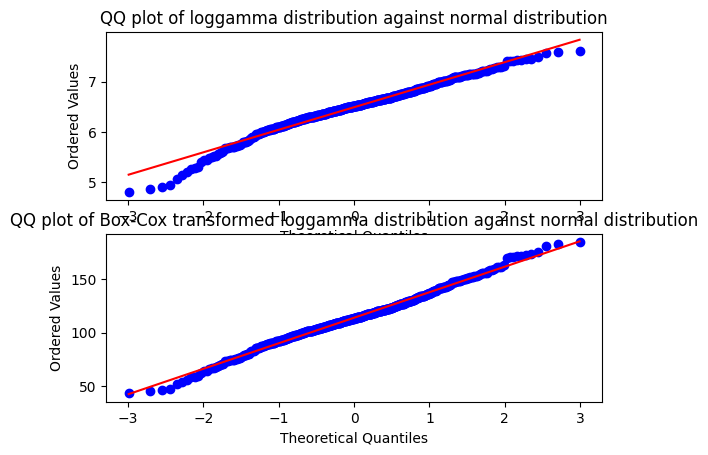

In [65]:
fig = plt.figure()
ax1 = fig.add_subplot(211)
x = stats.loggamma.rvs(5, size=500) + 5 # power law distrubutions
prob = stats.probplot(x, dist=stats.norm, plot=ax1)
ax1.set_xlabel("Theoretical Quantiles")
ax1.set_title("QQ plot of loggamma distribution against normal distribution")
ax2 = fig.add_subplot(212)
xt, _ = stats.boxcox(x)
prob = stats.probplot(xt, dist=stats.norm, plot=ax2)
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_title("QQ plot of Box-Cox transformed loggamma distribution against normal distribution")
plt.show()

# Application of non-gaussian distribution

In [ ]:
# Uniform, bernoulli, binomialm log-normal, power law, pareto distribution
# well studied distribution gives theoretical insights into the data and can help us make predictions
 

# Co-variance

In [66]:
# covariance(x, y) = 1/n * sum{i from 1 to n}[(xi - mu_x) * (yi - mu_y)] 
# if pos, then x inc, y inc 
# if negm then x dec, y inc and vice versa 

# if same dataset we capture covariance with different unit, then both covariance won't be same (Major drawback)


# Pearson correlation coefficient: (Pcc)
# P{x,y} = covariance(x, y) / (variance(x) * variance(y)) 
# can't capture non linear relations 

# Spearman rank (because pearson fails at non linear)
# sort and use ranks
# calculate person correlation coefficient of ranks

##### - Correlation does not imply causation

# Confidence Interval

In [67]:
# population mean, sample mean 

# Point estimate of population mean = sample mean

# Interval estimaton : there is 95% prob that mean lies in {x, y} => called confidence interval

In [68]:
# Question: X ~ F with pop mean of mue and standard deviation of sigma
# {x1, x2, .... x10} -> sample of size n = 10
# what is the 95% C.I of meu?


# Answer

# case 1: we know sigma of population
    # usig CLT
    # mean_sample (we have) = mean of population
    # sigma_sample = sigma_population / sqrt(size_of_sample)
    # and it will follow gaussian 
    # 95% -> [ mean_sample - 2 * sigma_sample, mean_sample + 2 * sigma_sample ]
    # sigma_sample = sigma_population / sqrt(size_of_sample)


# case 2: we don't know sigma of population
    # t-distribution
    # x_bar ~ t(n-1) : n -> degrees of freedom

In [69]:
# C.I of median, p90 etc
# steps (for median)
    # generate multiple samples
    # calculate medians of all
    # calculate C.I by picking medians accordingly so that much percentage (confidence percentage) lies between interval

# Same process can be used for others like p90 etc.

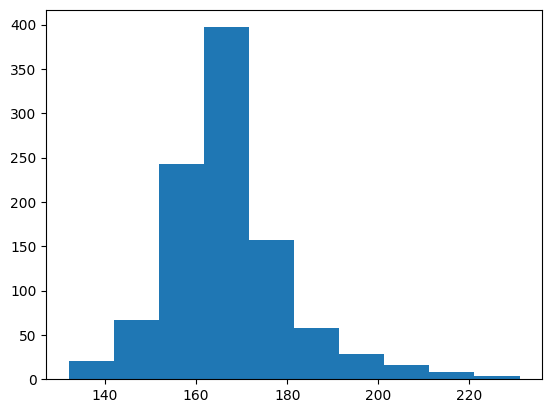

confidence interval: 95.0, lower: 145.0, upper: 204.5


In [85]:
# boot-strap based confidence internal

import numpy 
from pandas import read_csv
from sklearn.utils import resample
from sklearn.metrics import accuracy_score
from matplotlib import pyplot

x = numpy.array([180, 162, 159, 231, 145, 132, 148, 180, 192, 162, 178])

n_iterations = 1000
n_size = 4

medians = list()
for i in range(n_iterations):
    s = resample(x, n_samples=n_size)
    m = numpy.median(s)
    medians.append(m)

pyplot.hist(medians)
pyplot.show()

alpha = 0.95
p = ((1.0 - alpha) / 2.0) * 100
lower = numpy.percentile(medians, p)

p = (alpha + ((1.0 - alpha) / 2.0)) * 100
upper = numpy.percentile(medians, p)

print(f'confidence interval: {alpha * 100}, lower: {lower}, upper: {upper}')

# Hypothesis testing

In [86]:
# Question: is there is diff in heights of class 1 and class 2

# Hypothesis testing:
# choosing a test statistics (example: diff in mean height of class 1 and 2 -> = meu_2 - meu_1)
# null hypothesis (H0) (Proof y contradiction) <- neg sentiment (example: there is no difference between meu_1 and meu_2)
    # Alternative hypothesis (H1) <- positive sentiment (example: heights of meu_1 and meu_2 are different)
    # assume H0 is true and then proove H0 is incorrect then H1 will be true or vice versa.
# p-value: prob of observing "test statistic" if null hypothesis is true
    #  if big P value then accept H0 else H1

In [87]:
# Hypothesis testing and permutation test / resampling

# what is the prob of observing a value of X >= 10cm if there no diff in heights of classes?
    # P(X >= 10cm | H0 ) : prob of observing X >= 10 given H0 (there is no diff in heights of classes)
    # if p value is small (<= 5%): means H0 may not be true
    # If H0 says no diff, 
        # mix all, then separate again randomly, calculate diff between meu_1, meu_2 => multiple times
        # sort all deltas
        # check percentile of < 10cm
    # if we have chose H0 as not diff, we could not have been able to simulate and hence picking right H0 is important.


### Few Examples of Hypothesis testing

In [ ]:
# 1. Given a coin, determine if the coin is biased towards heads or not?

    # H0: is not biased towards heads
    # P(heads >= 50% time | given H0) : multiple experiments of 1000 flips, keep prob of heads for each experiment, sort them, find >= 50% ones percentage.
    # or find distribution and then answer.

# Kolmogorov - Smirnov test (K-S Test)

In [88]:
# if distribution of X1 and X2 are same or not?
    # plot cdfs
    # Dn,m = sup{x}|F{1,n}(x) - F{2,m}(x)|
    # null hypoths=esis is rejected at level alpha if 
    # D{n,m} > c(alpha) * sqrt((n+m)/(nm))
    # there is table of c(alpha)

# if gausian, normalize and then if ~ N(0, 1)


/var/folders/fy/lwhjv2_15kvf5gcd_746srd80000gn/T/ipykernel_90469/235064685.py:8: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(np.array(x), bw=0.5)


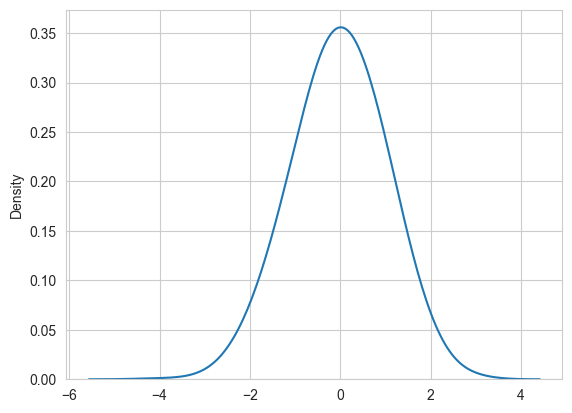

In [89]:
import numpy as np 
import seaborn as sns 
from scipy import stats 
import matplotlib.pyplot as plt 

x = stats.norm.rvs(size=1000)
sns.set_style('whitegrid')
sns.kdeplot(np.array(x), bw=0.5)
plt.show()

In [90]:
stats.kstest(x, 'norm')

KstestResult(statistic=np.float64(0.015663420610420253), pvalue=np.float64(0.9636501593061411), statistic_location=np.float64(0.3566860617416498), statistic_sign=np.int8(1))

/var/folders/fy/lwhjv2_15kvf5gcd_746srd80000gn/T/ipykernel_90469/445238033.py:2: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.1`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(np.array(y), bw=0.1)


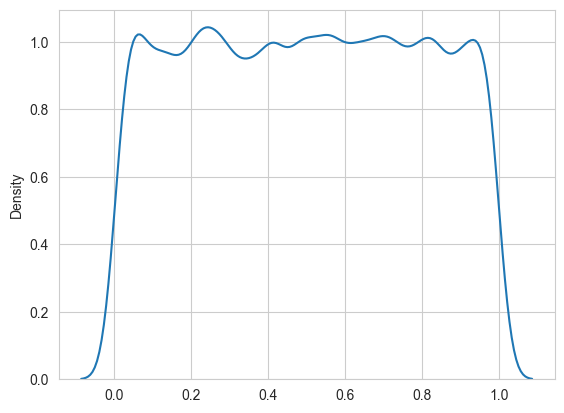

In [91]:
y = np.random.uniform(0, 1, 10000)
sns.kdeplot(np.array(y), bw=0.1)
plt.show()


In [92]:
stats.kstest(y, 'norm')

KstestResult(statistic=np.float64(0.5000544660110972), pvalue=np.float64(0.0), statistic_location=np.float64(0.00013652604384672973), statistic_sign=np.int8(-1))